Objective

Understand with REAL time-series:

Returns → movement over time
Volatility → risk over time
Correlation → relationships
OHLC → actual price behavior

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv("../data/stocks_data_2010_2020.csv")

df.columns = df.columns.str.strip().str.upper() # it is removing unnecesary space from column name and make it in upper case

df["DATE"] = pd.to_datetime(df["DATE"]) #
df = df.sort_values("DATE")
print(df["DATE"])

0      2009-12-31
1      2010-01-04
2      2010-01-05
3      2010-01-06
4      2010-01-07
          ...    
2755   2020-12-10
2756   2020-12-11
2757   2020-12-14
2758   2020-12-15
2759   2020-12-16
Name: DATE, Length: 2760, dtype: datetime64[ns]


In [10]:
df.columns

Index(['DATE', 'AMAZON', 'APPLE', 'WALMART', 'MICRON', 'BANK OF AMERICA',
       'COCA-COLA', 'BOEING', 'AMERICAN EXPRESS'],
      dtype='object')

STEP 3 — SELECT ONE STOCK (VERY IMPORTANT)

In [ ]:
stock = df["AMAZON"].round(2) # df["AMAZON"] → gives time-series of Amazon prices
stock

0         6.49
1         6.59
2         6.60
3         6.50
4         6.49
         ...  
2755    123.24
2756    122.41
2757    121.78
2758    127.88
2759    127.81
Name: AMAZON, Length: 2760, dtype: float64

Plot-Price trend

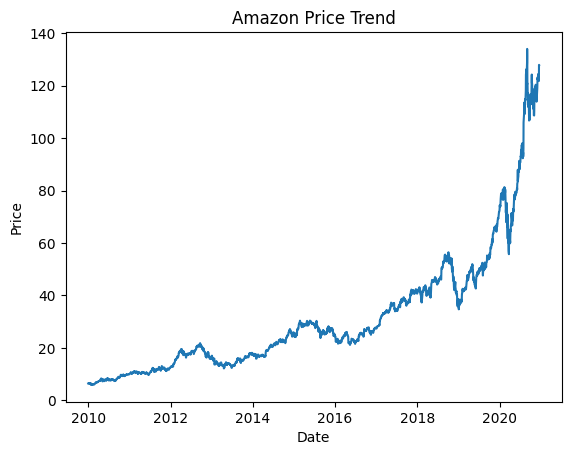

In [16]:
plt.plot(df["DATE"], stock)

plt.title("Amazon Price Trend")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

In [17]:
returns = stock.pct_change() # pct_change() → calculates daily returns
returns

0            NaN
1       0.015408
2       0.001517
3      -0.015152
4      -0.001538
          ...   
2755    0.011989
2756   -0.006735
2757   -0.005147
2758    0.050090
2759   -0.000547
Name: AMAZON, Length: 2760, dtype: float64

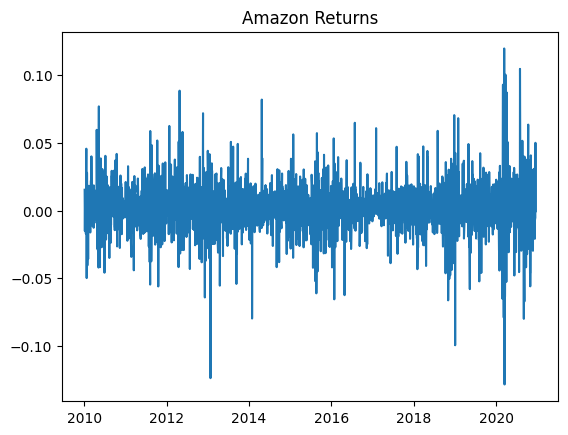

In [18]:
plt.plot(df["DATE"], returns) #plot returns

plt.title("Amazon Returns")
plt.show()

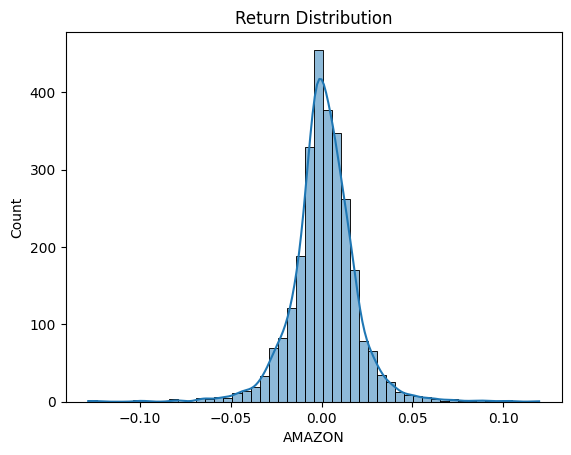

In [19]:
#Return Distrinution
sns.histplot(returns.dropna(), bins=50, kde=True)

plt.title("Return Distribution")

plt.show()

In [20]:
#volatility
volatility = np.std(returns.dropna())

print(volatility)

0.01783559751903367


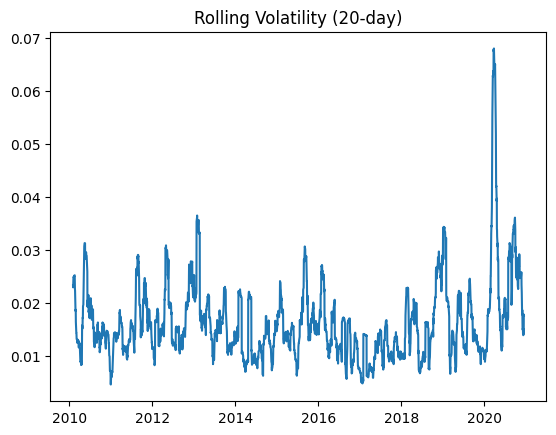

In [ ]:
#Rolling volatility
rolling_vol = returns.rolling(20).std()

plt.plot(df["DATE"], rolling_vol)

plt.title("Rolling Volatility (20-day)")

plt.show()

 MULTI-STOCK ANALYSIS (THIS IS POWERFUL)

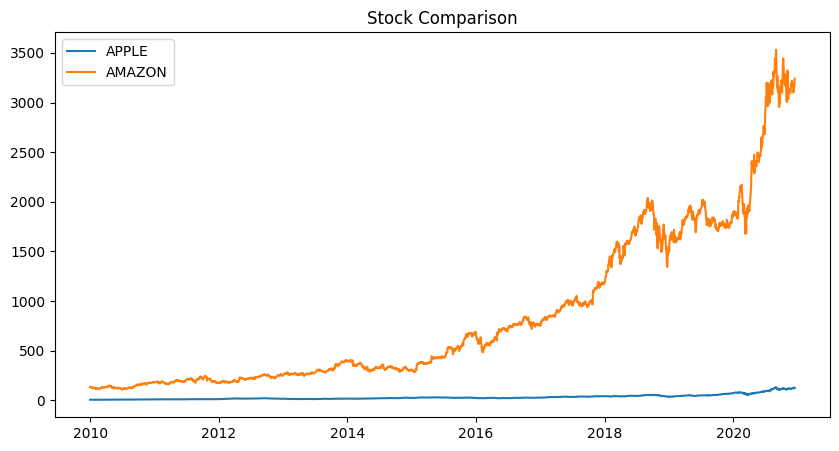

In [25]:
plt.figure(figsize=(10,5))

plt.plot(df["DATE"], df["AMAZON"], label="APPLE")
plt.plot(df["DATE"], df["APPLE"], label="AMAZON")

plt.legend()
plt.title("Stock Comparison")

plt.show()

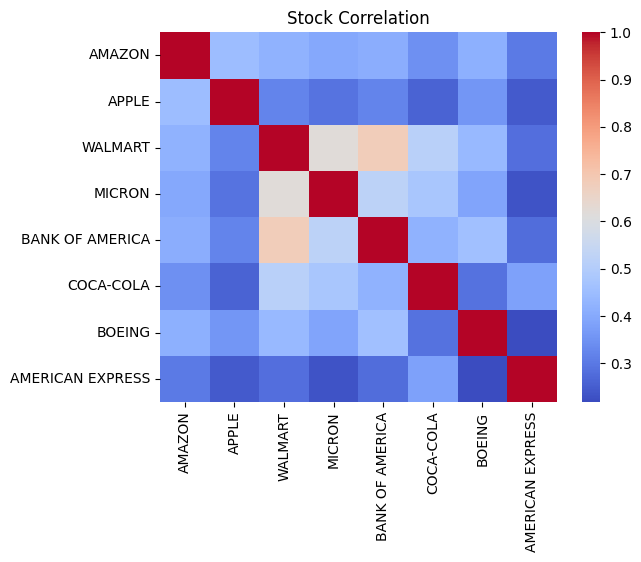

In [26]:
#COORELATION

returns_df = df.drop(columns=["DATE"]).pct_change()

corr = returns_df.corr()

sns.heatmap(corr, cmap="coolwarm")

plt.title("Stock Correlation")

plt.show()

Biggest Mover

In [27]:
last_returns = returns_df.iloc[-1]

top_gainers = last_returns.sort_values(ascending=False).head(5)
top_losers = last_returns.sort_values().head(5)

print("Top Gainers:\n", top_gainers)
print("Top Losers:\n", top_losers)

Top Gainers:
 APPLE               0.023961
BANK OF AMERICA     0.002793
AMAZON             -0.000547
WALMART            -0.000840
AMERICAN EXPRESS   -0.001030
Name: 2759, dtype: float64
Top Losers:
 MICRON             -0.015817
COCA-COLA          -0.014487
BOEING             -0.002187
AMERICAN EXPRESS   -0.001030
WALMART            -0.000840
Name: 2759, dtype: float64


In [ ]:
# Insights:
# 1. Returns represent daily percentage movement of stocks.
# 2. Volatility shows risk and changes over time.
# 3. Rolling volatility captures dynamic market conditions.
# 4. Correlation shows how stocks move together.
# 5. Multi-stock comparison helps identify outperformers.